<a href="https://colab.research.google.com/github/Aswin-k61/NLP_Repo/blob/main/Generated_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
data={
    "text": [
        "I love this product, it's amazing!",
        "This is the worst experience ever.",
        "It's okay, nothing special.",
        "Absolutely fantastic service!",
        "I hate this item, very bad quality.",
        "Not bad, could be better.",
        "I'm very happy with my purchase.",
        "Terrible, I will not buy again.",
        "Average experience, nothing great.",
        "Excellent! Highly recommend it."
    ],
    "sentiment": [
        "positive",
        "negative",
        "neutral",
        "positive",
        "negative",
        "neutral",
        "positive",
        "negative",
        "neutral",
        "positive"
    ]
}
df=pd.DataFrame(data)
df.head()

,text,sentiment
0,"I love this product, it's amazing!",positive
1,This is the worst experience ever.,negative
2,"It's okay, nothing special.",neutral
3,Absolutely fantastic service!,positive
4,"I hate this item, very bad quality.",negative


In [6]:
stop_words=set(stopwords.words('english'))
stemmer=PorterStemmer()

def preprocess(text):

  text=text.lower()

  text=text.translate(
  str.maketrans('','',string.punctuation)
  )
  words=text.split()

  words=[w for w in words if w not in stop_words]

  words=[stemmer.stem(w) for w in words]

  return " ".join(words)

df["clean"]=df["text"].apply(preprocess)

vectorizer=TfidfVectorizer()

X=vectorizer.fit_transform(df["clean"])
y=df["sentiment"]

In [7]:
model=LogisticRegression()
model.fit(X,y)

LogisticRegression()

In [8]:
input=["Excellent wonderful fantastic produc"]

clean=preprocess(input[0])

vector=vectorizer.transform([clean])

prediction=model.predict(vector)

print("Sentiment:",prediction[0])

Sentiment: positive


<BarContainer object of 3 artists>

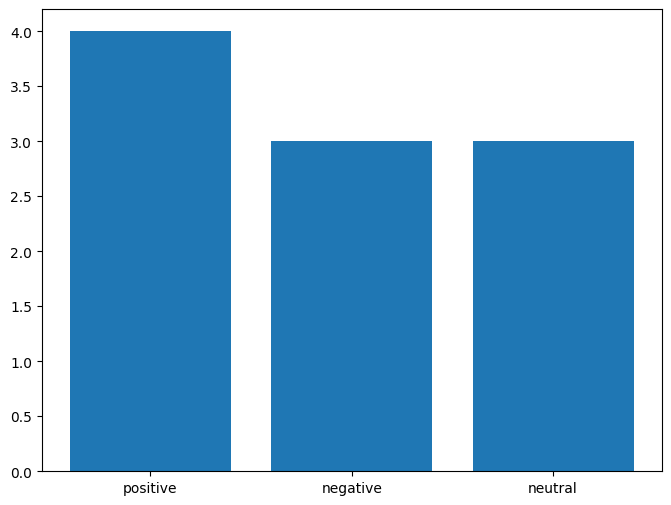

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.bar(y.value_counts().index,y.value_counts().values)